# Beta distribution

Below the beta distribution is plotted for different alpha and beta pairs.

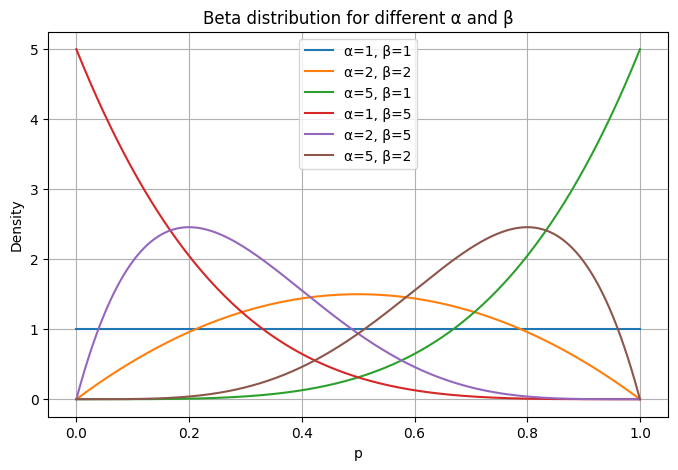

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

x = np.linspace(0, 1, 500)

params = [
    (1, 1),   # uniform
    (2, 2),   # symmetric
    (5, 1),   # skewed to 1
    (1, 5),   # skewed to 0
    (2, 5),   # moderate skew
    (5, 2),   # opposite skew
]

plt.figure(figsize=(8, 5))

for a, b in params:
    y = beta.pdf(x, a, b)
    plt.plot(x, y, label=f"α={a}, β={b}")

plt.title("Beta distribution for different α and β")
plt.xlabel("p")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

You can use the function plot_beta(a,b) to plot different pairs of alpha and beta yourself.

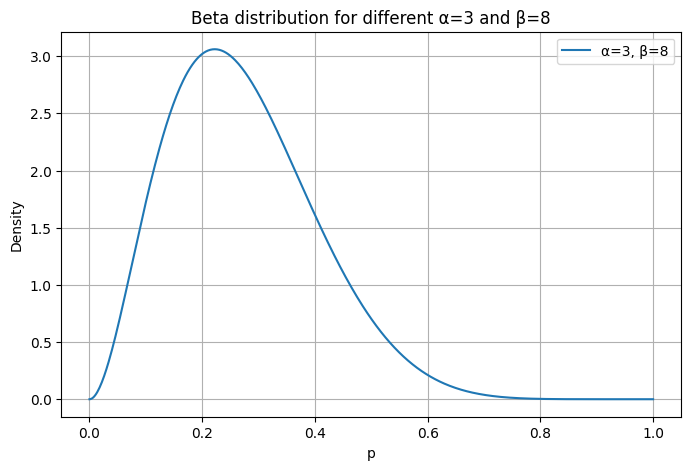

In [ ]:
def plot_beta(a, b):
    
    plt.figure(figsize=(8, 5))
    x = np.linspace(0, 1, 500)

    y = beta.pdf(x, a, b)
    plt.plot(x,y,label=f"α={a}, β={b}")

    plt.title(f"Beta distribution for different α={a} and β={b}")
    plt.xlabel("p")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)

    plt.show()

plot_beta(a=3,b=8)
 

# Updating the beta distribution

With the function update_beta(data, prior) you can visualize an update of the beta distribution with data.

The posterior distribution is again a beta distribution with parameters:
- alpha prior distribution + n_successes
- beta prior distribution + n_failures

This way of computing the posterior distribution gives the same result as applying bayes formula and is proportional to likelihood*prior. With the update beta function you can test this by choosing type_posterior = "formula".

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.special import comb

def update_beta(data: tuple[int, int], prior: tuple[int, int], type_posterior = None) -> plt:
    
    x = np.linspace(0, 1, 500)

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # plot the prior beta distribution
    ax1.plot(
        x, beta.pdf(x, prior[0], prior[1]),
        label=f"Prior α={prior[0]}, β={prior[1]}",
        linestyle='--'
    )

    # compute likelihood of the data P(data | p) 
    n = data[0] + data[1]
    likelihood = comb(n, data[0]) * (x ** data[0]) * ((1 - x) ** data[1])

    # plot posterior
    alpha_post = prior[0] + data[0]
    beta_post = prior[1] + data[1]
    
    if type_posterior == "formula":
        posterior_unnorm = likelihood*beta.pdf(x, prior[0], prior[1])
        posterior = posterior_unnorm / np.trapezoid(posterior_unnorm, x)
    else:
        posterior = beta.pdf(x, alpha_post, beta_post)

    ax1.plot(
        x, posterior,
        label=f"Posterior α={alpha_post}, β={beta_post}"
    )

    #ax1.set_title("title")
    ax1.set_xlabel("p (probability of success)")
    ax1.set_ylabel("Beta density")
    ax1.grid(True)

    # plot the likelihood on second axis (note: different scales, not a probability)
    ax2 = ax1.twinx()
    ax2.plot(
        x, likelihood,
        color='red',
        label="Likelihood P(data | p)",
        alpha=0.7
    )
    ax2.set_ylabel("Likelihood")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.show()

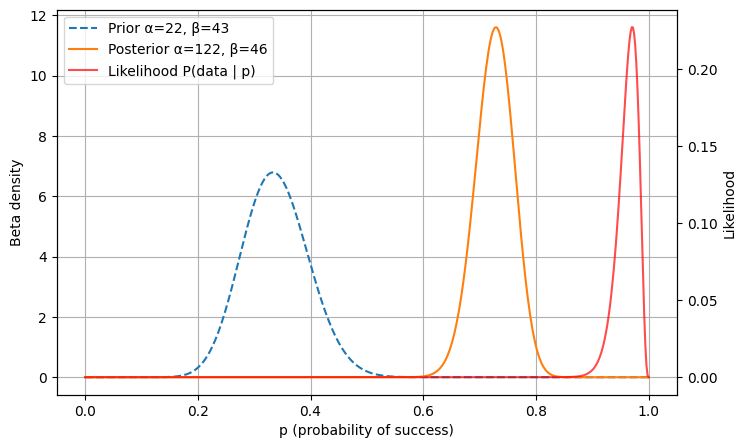

In [ ]:
# update with beta distribution parameters
update_beta([100, 3], [22, 43])

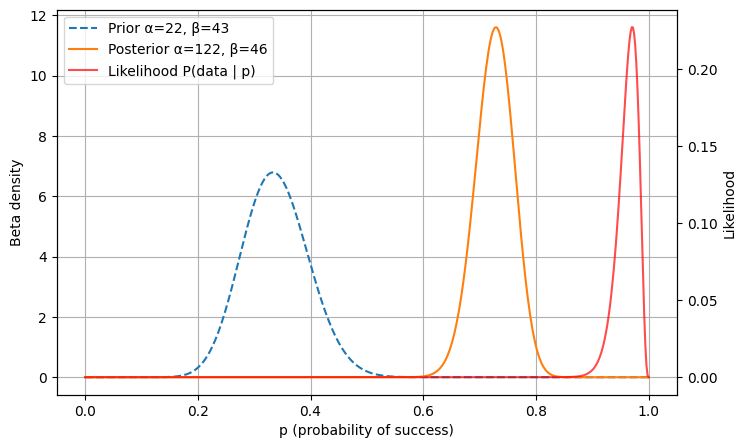

In [ ]:
# update with bayes formula
update_beta([100, 3], [22, 43], type_posterior="formula")

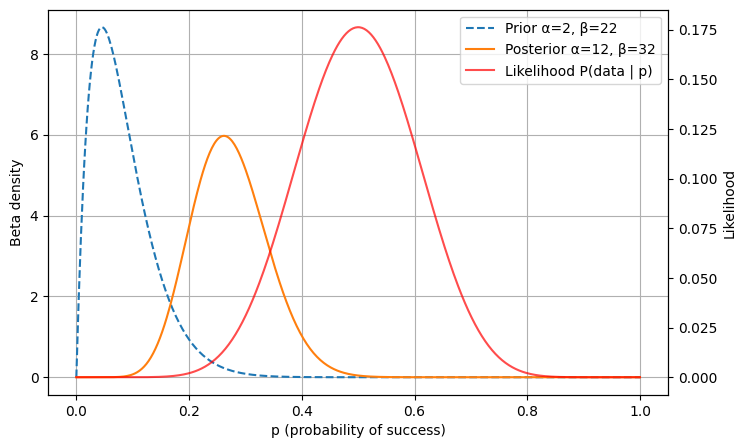

In [56]:
# effect strong prior: posterior skews towards the prior
update_beta([10, 10], [2, 22])

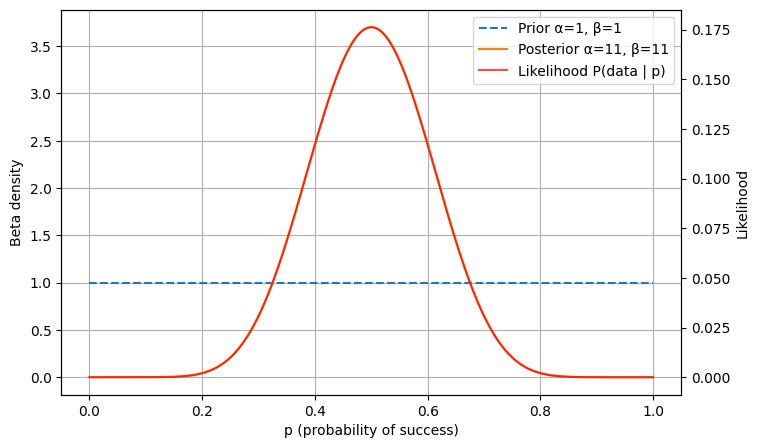

In [ ]:
# effect uninformate prior: posterior dominated by the data
update_beta([10, 10], [1,1])


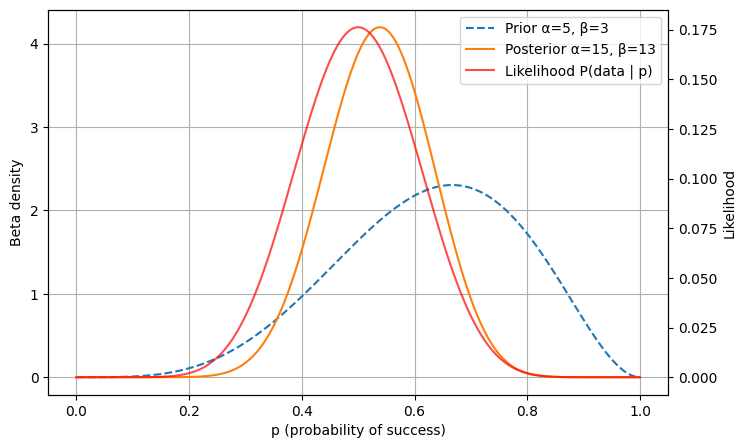

In [ ]:
# effect week prior: posterior skews towards the data
update_beta([10, 10], [5, 3])

# Credibility interval

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def plot_posterior_with_credible_interval(
    count_pos,
    count_neg,
    alpha_prior=1,
    beta_prior=1,
    ci=0.95
):
    # posterior parameters
    alpha_post = alpha_prior + count_pos
    beta_post = beta_prior + count_neg

    x = np.linspace(0, 1, 1000)
    y = beta.pdf(x, alpha_post, beta_post)

    # Equal-tailed credible interval
    lower = beta.ppf((1 - ci) / 2, alpha_post, beta_post)
    upper = beta.ppf(1 - (1 - ci) / 2, alpha_post, beta_post)
    mean_post = alpha_post / (alpha_post + beta_post)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, label=f"Posterior Beta({alpha_post}, {beta_post})")

    # Shade credible interval
    mask = (x >= lower) & (x <= upper)
    plt.fill_between(x[mask], y[mask], alpha=0.3,
                     label=f"{int(ci*100)}% credible interval")

    # Vertical lines
    plt.axvline(lower, linestyle="--", label=f"Lower = {lower:.3f}")
    plt.axvline(upper, linestyle="--", label=f"Upper = {upper:.3f}")
    plt.axvline(mean_post, linestyle=":", label=f"Posterior mean = {mean_post:.3f}")

    plt.title("Posterior with credible interval")
    plt.xlabel("p")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"{int(ci*100)}% credible interval: [{lower:.4f}, {upper:.4f}]")
    print(f"Posterior mean: {mean_post:.4f}")

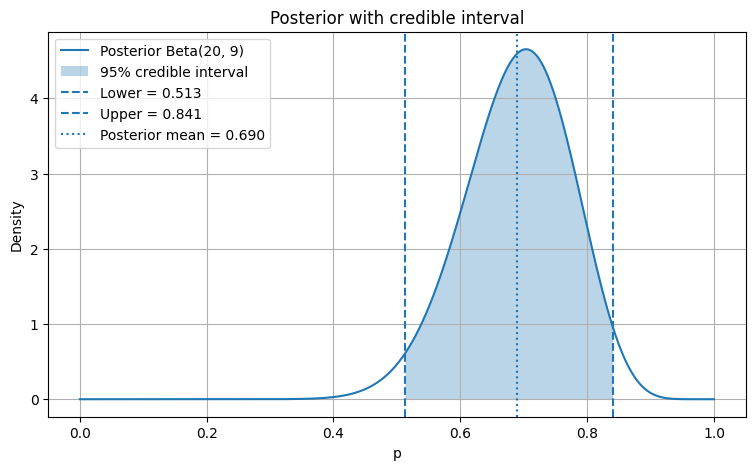

95% credible interval: [0.5133, 0.8412]
Posterior mean: 0.6897


In [8]:
plot_posterior_with_credible_interval(
    count_pos=18,
    count_neg=7,
    alpha_prior=2,
    beta_prior=2,
    ci=0.95
)